# Preferencias de modalidad académica

El dataset contiene información estructurada relacionada con una universidad privada. Incluye 500 registros y 6 variables, con datos numéricos y categóricos.

### Importación de Librerías

Se importan las librerías necesarias para el análisis y visualización de datos:
- `pandas` para la manipulación de datos usando DataFrames.
- `matplotlib.pyplot` para crear gráficos básicos y personalizables.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### Carga del Dataset de Modalidad

Esta sección carga el dataset que contiene información de aspirantes y sus preferencias de modalidad en un DataFrame de pandas, permitiendo su manipulación, análisis y visualización posterior.

In [2]:
try:
  modalidad = pd.read_csv("cleaned_modalidad.csv")
  df_modalidad = modalidad.copy()
  print("File was loaded with success and save as dataframe!")
  print(f"Count of rows and columns: {df_modalidad.shape}")
except FileNotFoundError:
  print("Error: cleaned_modalidad.csv was not found.")

File was loaded with success and save as dataframe!
Count of rows and columns: (500, 6)


**Información del DataFrame `df_modalidad`**

In [3]:
df_modalidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              500 non-null    int64 
 1   Edad            500 non-null    int64 
 2   Municipio       500 non-null    object
 3   NivelEducativo  500 non-null    object
 4   Programa        500 non-null    object
 5   Modalidad       500 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.6+ KB


**Primeras filas del DataFrame `df_modalidad`**

In [4]:
df_modalidad.head()

,ID,Edad,Municipio,NivelEducativo,Programa,Modalidad
0,1,18,Bayamón,Bachillerato,Biología Enfoque Humano,Presencial
1,2,19,Toa Baja,Bachillerato,Ciencias de Computadoras,Híbrido
2,3,17,Guaynabo,Bachillerato,Biología General,Presencial
3,4,24,San Juan,Maestría,Administración de Empresas,Distancia
4,5,21,Cataño,Bachillerato,Educación Física Especial,Presencial


**Mostrar conteo de valores por columna**

In [5]:
def show_value(df, column):
    print(df[column].value_counts().sort_index())

try:
    column_name = input("Enter the column name: ") or "Municipio"
    
    if not column_name.strip():
        print("You entered an empty value.")
    else:
        column_name = column_name.strip().title()
        show_value(df_modalidad, column_name)

except Exception as e:
    print(f"An error ocurred: {e}")

Municipio
Bayamón      94
Cataño       42
Corozal      30
Dorado       45
Guaynabo     49
Naranjito    41
San Juan     70
Toa Alta     50
Toa Baja     53
Vega Alta    15
Vega Baja    11
Name: count, dtype: int64


### Análisis Descriptivo

El análisis descriptivo resume y describe las principales características de un dataset.
Ayuda a comprender patrones, tendencias y estadísticas básicas.

**Análisis de Datos de Estudiantes**

In [6]:
average_age = df_modalidad['Edad'].mean()
print(f"La edad promedio de los estudiantes es {average_age:.0f} años")

La edad promedio de los estudiantes es 20 años


**Mostrar las 5 Ciudades con Más Estudiantes**

In [7]:
city_distribution = df_modalidad['Municipio'].value_counts()
print("Distribución de estudiantes por ciudad (top 5):")
print(city_distribution.head())

Distribución de estudiantes por ciudad (top 5):
Municipio
Bayamón     94
San Juan    70
Toa Baja    53
Toa Alta    50
Guaynabo    49
Name: count, dtype: int64


**Tabla Cruzada de Programas y Modalidades por Nivel Educativo**

In [8]:
niveles = df_modalidad['NivelEducativo'].unique()

for nivel in niveles:
    # Filtrar por nivel
    nivelEducativo = df_modalidad.query('NivelEducativo == @nivel')
    
    print(f"\nInformación del nivel educativo: {nivel}")
    
    # Tabla cruzada por Programa y Modalidad
    tabla = pd.crosstab(
        index=nivelEducativo['Programa'],
        columns=nivelEducativo['Modalidad'],
        margins=True  # agrega totales
    )
    
    print(tabla)


Información del nivel educativo: Bachillerato
Modalidad                       Distancia  Híbrido  Presencial  All
Programa                                                           
Administración de Empresas              5        7          28   40
Biología Enfoque Humano                 4       15          39   58
Biología General                        5       17          31   53
Ciencias de Computadoras               12       24          21   57
Educación Física Especial               9       10          23   42
Educación Pre-Escolar                   8       11          24   43
Gerencia de Materiales                  6       11          15   32
Sistemas de Oficina                    11       11          22   44
Tecnología de Ing. Electrónica         11       12          26   49
All                                    71      118         229  418

Información del nivel educativo: Maestría
Modalidad                       Distancia  Híbrido  All
Programa                              

**Tabla Cruzada para un Nivel Educativo Específico**

In [9]:
nivel = input("Ingrese el NivelEducativo que desea ver: ") or "Bachillerato"

# Filtrar solo Bachillerato usando query
nivelEducativo = df_modalidad.query('NivelEducativo == @nivel')

print(f"Informacion del nivel educativo de {nivel}")
pd.crosstab(
    index=[nivelEducativo['Programa']],
    columns=nivelEducativo["Modalidad"],
    margins=True  # agrega totales
)

Informacion del nivel educativo de Bachillerato


Modalidad,Distancia,Híbrido,Presencial,All
Programa,,,,
Administración de Empresas,5,7,28,40
Biología Enfoque Humano,4,15,39,58
Biología General,5,17,31,53
Ciencias de Computadoras,12,24,21,57
Educación Física Especial,9,10,23,42
Educación Pre-Escolar,8,11,24,43
Gerencia de Materiales,6,11,15,32
Sistemas de Oficina,11,11,22,44
Tecnología de Ing. Electrónica,11,12,26,49


**Encontrar la Ciudad con Más Estudiantes**

In [10]:
conteo_municipio = df_modalidad["Municipio"].value_counts()
print(f"Municipio con mas estudiantes: {conteo_municipio.idxmax()}")

Municipio con mas estudiantes: Bayamón


**Tabla Cruzada de Estudiantes Menores de 18 Años**

In [11]:
# Filtrar estudiantes menores de 18
menores = df_modalidad.query("Edad < 18")

print(f"Tabla de estudiantes menores de 18 años")
pd.crosstab(
    index=[menores['NivelEducativo'], menores['Programa']],
    columns=menores["Modalidad"],
    margins=True  # agrega totales
)

Tabla de estudiantes menores de 18 años


Modalidad                                      Distancia  Híbrido  Presencial  \
NivelEducativo Programa                                                         
Bachillerato   Administración de Empresas              0        1           4   
               Biología Enfoque Humano                 1        0           2   
               Biología General                        0        1           7   
               Ciencias de Computadoras                0        0           1   
               Educación Física Especial               0        0           4   
               Educación Pre-Escolar                   1        3           8   
               Gerencia de Materiales                  0        0           1   
               Sistemas de Oficina                     0        0           3   
               Tecnología de Ing. Electrónica          0        2           3   
All                                                    2        7          33   

Modalidad                                      All  
NivelEducativo Programa                             
Bachillerato   Administración de Empresas        5  
               Biología Enfoque Humano           3  
               Biología General                  8  
               Ciencias de Computadoras          1  
               Educación Física Especial         4  
               Educación Pre-Escolar            12  
               Gerencia de Materiales            1  
               Sistemas de Oficina               3  
               Tecnología de Ing. Electrónica    5  
All                                             42

**Conteo de Estudiantes en Modalidad a Distancia**

In [12]:
distancia = df_modalidad.query("Modalidad == 'Distancia'")
conteo_distancia = distancia["NivelEducativo"].value_counts()

print("Conteo de estudiantes por modalidad a distancia:")
print(conteo_distancia)

Conteo de estudiantes por modalidad a distancia:
NivelEducativo
Bachillerato        71
Maestría            22
Certificado Esp.    15
Grado Asociado       4
Doctorado            3
Name: count, dtype: int64


**Edad Promedio por Municipio**

In [13]:
# Group by city and calculate the mean age
edad_promedio = df_modalidad.groupby("Municipio")["Edad"].mean().round()
print("La edad promedio por municipio:")
print(edad_promedio)

La edad promedio por municipio:
Municipio
Bayamón      19.0
Cataño       21.0
Corozal      20.0
Dorado       19.0
Guaynabo     21.0
Naranjito    20.0
San Juan     22.0
Toa Alta     20.0
Toa Baja     21.0
Vega Alta    21.0
Vega Baja    21.0
Name: Edad, dtype: float64


**Edad Mínima y Máxima por Municipio**

In [14]:
# Edad mínima y máxima por municipio
edad_rango = df_modalidad.groupby("Municipio")["Edad"].agg(['min','max'])
print("Minimo y máxima por municipio:")
print(edad_rango)

Minimo y máxima por municipio:
           min  max
Municipio          
Bayamón     17   29
Cataño      17   23
Corozal     17   26
Dorado      17   28
Guaynabo    17   27
Naranjito   17   25
San Juan    17   30
Toa Alta    18   26
Toa Baja    17   30
Vega Alta   18   28
Vega Baja   17   26


**Gráfico de barras de la distribución de modalidades**

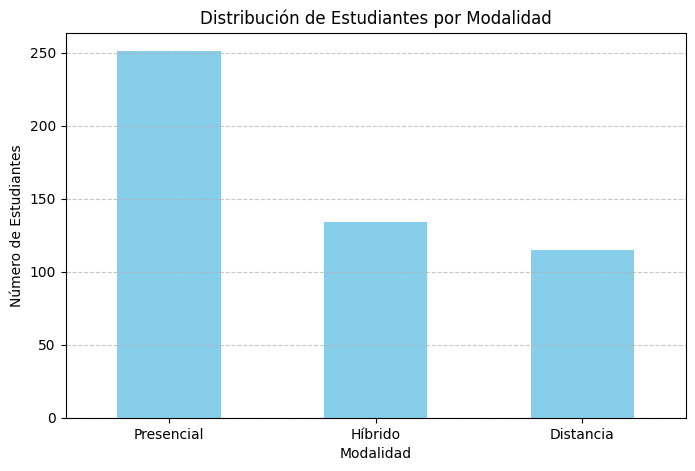

In [15]:
modalidades_count = df_modalidad['Modalidad'].value_counts()

plt.figure(figsize=(8,5))
modalidades_count.plot(kind='bar', color='skyblue')
plt.title("Distribución de Estudiantes por Modalidad")
plt.xlabel("Modalidad")
plt.ylabel("Número de Estudiantes")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()